In [20]:
# Standard library
import warnings
from pathlib import Path
from typing import Optional

# Data manipulation
import numpy as np
import pandas as pd

# Statistical functions
from scipy.stats import pearsonr, spearmanr, zscore, norm
import statsmodels.api as sm

# Machine learning & modeling
from sklearn.compose import ColumnTransformer
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
    VotingRegressor
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    GroupKFold,
    KFold,
    TimeSeriesSplit,
    cross_validate
)
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Explainability
import shap

# Visualization
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Suppress warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV, LassoCV

In [ ]:
# OS-portable 한글 폰트 셋업
import platform
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

_OS = platform.system()
_CANDIDATES = {
    'Windows': ['Malgun Gothic', 'NanumSquareR', 'NanumGothic'],
    'Darwin':  ['AppleGothic', 'NanumGothic'],
    'Linux':   ['NanumGothic', 'DejaVu Sans'],
}.get(_OS, ['DejaVu Sans'])

_installed = {f.name for f in fm.fontManager.ttflist}
_chosen = next((c for c in _CANDIDATES if c in _installed), 'DejaVu Sans')
plt.rcParams['font.family'] = _chosen
plt.rcParams['axes.unicode_minus'] = False
print(f'matplotlib font: {_chosen} (OS={_OS})')


In [15]:
df = pd.read_csv('../data/final/fatigue_with_index.csv')

Optimization terminated successfully.
         Current function value: 0.564781
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 회복실패여부   No. Observations:                17528
Model:                          Logit   Df Residuals:                    17526
Method:                           MLE   Df Model:                            1
Date:                Wed, 28 May 2025   Pseudo R-squ.:                 0.01016
Time:                        03:27:03   Log-Likelihood:                -9899.5
converged:                       True   LL-Null:                       -10001.
Covariance Type:            nonrobust   LLR p-value:                 4.033e-46
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6123      0.035     17.365      0.000       0.543       0.681
피로도지수          0.0098      0.

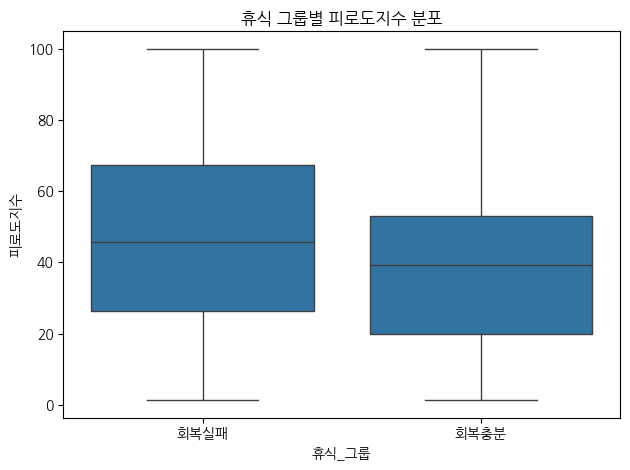

In [16]:
# ✅ 2. 회복실패 여부 / 부상위험도 예측

# 1) 로지스틱 회귀: 회복실패여부 ~ 피로도지수
df_model = df[['피로도지수', '회복실패여부']].dropna()
X = sm.add_constant(df_model['피로도지수'].astype(float))
y = df_model['회복실패여부'].astype(int)
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

# 2) 피로도지수 ↔ 부상위험도 상관
corr_df = df[['피로도지수', '부상위험도']].dropna()
print("부상위험도와 피로도지수 상관:")
print("Pearson r:", pearsonr(corr_df['피로도지수'], corr_df['부상위험도']))
print("Spearman ρ:", spearmanr(corr_df['피로도지수'], corr_df['부상위험도']))

# 3) 휴식_그룹별 피로도지수 boxplot
sns.boxplot(data=df.dropna(subset=['피로도지수', '휴식_그룹']), x='휴식_그룹', y='피로도지수')
plt.title('휴식 그룹별 피로도지수 분포')
plt.tight_layout()
plt.show()

In [17]:
# ✅ 3. 누적 변수와의 상관관계
for var in ['누적연투일수', '연투횟수', '연투일수', '연투일수_roll3']:
    sub = df[['피로도지수', var]].dropna()
    if not sub.empty:
        rho, p = spearmanr(sub['피로도지수'], sub[var])
        print(f"{var} ↔ 피로도지수: Spearman ρ = {rho:.3f}, p = {p:.3f}")

누적연투일수 ↔ 피로도지수: Spearman ρ = 0.462, p = 0.000
연투횟수 ↔ 피로도지수: Spearman ρ = -0.066, p = 0.000
연투일수 ↔ 피로도지수: Spearman ρ = 0.462, p = 0.000
연투일수_roll3 ↔ 피로도지수: Spearman ρ = -0.112, p = 0.000


In [18]:
# ✅ 4. 휴식 변수와의 상관관계
for var in ['휴식일수', '휴식일수_prev', '휴식_inv']:
    sub = df[['피로도지수', var]].dropna()
    if not sub.empty:
        rho, p = spearmanr(sub['피로도지수'], sub[var])
        print(f"{var} ↔ 피로도지수: Spearman ρ = {rho:.3f}, p = {p:.3f}")

휴식일수 ↔ 피로도지수: Spearman ρ = -0.282, p = 0.000
휴식일수_prev ↔ 피로도지수: Spearman ρ = 0.148, p = 0.000
휴식_inv ↔ 피로도지수: Spearman ρ = -0.148, p = 0.000


In [19]:
# ✅ 5. 특수 이벤트 참여 여부에 따른 피로도 비교 (t-test)
for col in ['WBC_2023', 'PS_KS', '아시안게임_2023']:
    if col in df.columns:
        sub = df[[col, '피로도지수']].dropna()
        group1 = sub[sub[col] == 1]['피로도지수']
        group0 = sub[sub[col] == 0]['피로도지수']
        if not group1.empty and not group0.empty:
            t, p = ttest_ind(group1, group0, equal_var=False)
            print(f"{col} 참여 여부에 따른 피로도지수 차이: t = {t:.3f}, p = {p:.3f}")

WBC_2023 참여 여부에 따른 피로도지수 차이: t = 2.638, p = 0.008
PS_KS 참여 여부에 따른 피로도지수 차이: t = -0.227, p = 0.820
아시안게임_2023 참여 여부에 따른 피로도지수 차이: t = 3.276, p = 0.001


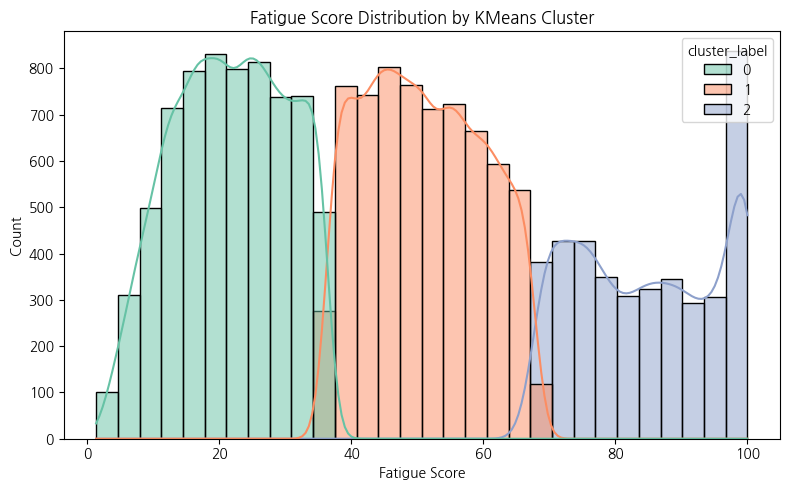

   cluster_label        min         max       mean
0              0   1.304814   36.235550  21.609639
1              1  36.242455   67.822716  51.095652
2              2  67.852397  100.000000  84.805597


In [23]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

fatigue_score = df['피로도지수']

# ▶ 2. KMeans 클러스터링 (3개 클러스터)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(fatigue_score.values.reshape(-1, 1))  # 수정된 부분

# ▶ 3. 결과 데이터프레임 구성
df_clusters = pd.DataFrame({
    'fatigue_score': fatigue_score,
    'cluster': clusters
})

# ▶ 4. 클러스터를 평균 기준으로 정렬하여 의미 부여
cluster_order = df_clusters.groupby('cluster')['fatigue_score'].mean().sort_values().index
cluster_map = {old: new for new, old in enumerate(cluster_order)}
df_clusters['cluster_label'] = df_clusters['cluster'].map(cluster_map)

# ▶ 5. 시각화
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clusters, x='fatigue_score', hue='cluster_label', bins=30, palette='Set2', kde=True)
plt.title('Fatigue Score Distribution by KMeans Cluster')
plt.xlabel('Fatigue Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ▶ 6. 클러스터별 통계 요약
cluster_ranges = df_clusters.groupby('cluster_label')['fatigue_score'].agg(['min', 'max', 'mean']).reset_index()
print(cluster_ranges)

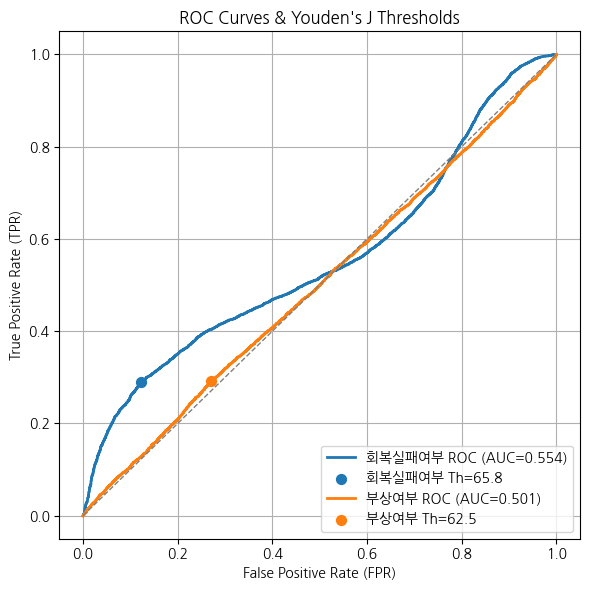

In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. (예시) df 준비: 실제 df 사용하세요
# np.random.seed(42)
# df = pd.DataFrame({
#     '피로도지수': ...,
#     '회복실패여부': ...,
#     '부상여부': ...
# })

y_true_list  = [df['회복실패여부'], df['부상여부']]
labels       = ['회복실패여부', '부상여부']
colors       = ['tab:blue', 'tab:orange']

plt.figure(figsize=(6,6))

for y_true, label, color in zip(y_true_list, labels, colors):
    # ROC, AUC
    fpr, tpr, thresholds = roc_curve(y_true, df['피로도지수'])
    auc = roc_auc_score(y_true, df['피로도지수'])
    
    # Youden’s J
    J = tpr - fpr
    ix = np.argmax(J)
    best_thresh = thresholds[ix]
    
    # ROC curve
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{label} ROC (AUC={auc:.3f})')
    # 최적 임계점
    plt.scatter(fpr[ix], tpr[ix], color=color, s=50, marker='o',
                label=f'{label} Th={best_thresh:.1f}')
    
# 대각선 랜덤 기준
plt.plot([0,1], [0,1], '--', color='gray', lw=1)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title("ROC Curves & Youden's J Thresholds")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
df['부상여부'] = df['부상위험도'].notna() & (df['부상위험도'] > 0)

GridSearch 최적 파라미터: {'max_depth': 4, 'min_samples_leaf': 10}
선택된 위험 경고 임계값: 3.7319897413253784


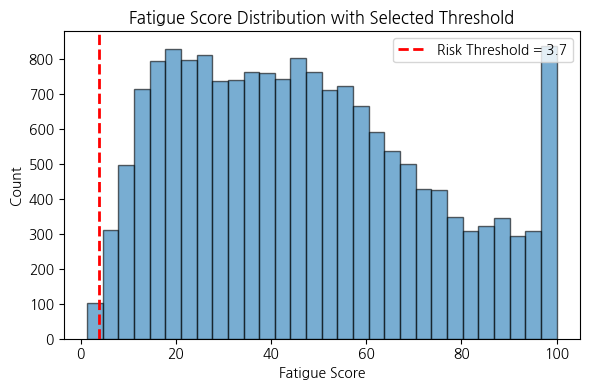

In [41]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ── 1. 데이터 준비 ──
# 실제 df 사용; df에 '피로도지수' 및 '회복실패여부' 컬럼이 있다고 가정합니다.
X = df[['피로도지수']].values
y = df['부상여부'].values

# ── 2. 하이퍼파라미터 튜닝 ──
param_grid = {
    'max_depth': [1, 2, 3, 4],
    'min_samples_leaf': [5, 10, 20]
}
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc'
)
grid.fit(X, y)

# 최적 모델 및 임계값 추출
best_clf = grid.best_estimator_
thr_best = [t for t in best_clf.tree_.threshold if t != -2][0]
print("GridSearch 최적 파라미터:", grid.best_params_)
print("선택된 위험 경고 임계값:", thr_best)

# ── 3. 임계값 시각화 ──
plt.figure(figsize=(6, 4))
plt.hist(df['피로도지수'], bins=30, edgecolor='k', alpha=0.6)
plt.axvline(thr_best, color='red', linestyle='--', linewidth=2,
            label=f'Risk Threshold = {thr_best:.1f}')
plt.title("Fatigue Score Distribution with Selected Threshold")
plt.xlabel("Fatigue Score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

